In [1]:
import argparse
import sys
from dataclasses import dataclass, field, fields
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
from ase.io import read

from max_flow import compute_backbone, compute_max_flow


@dataclass
class FlowConfig:
    """All parameters for one max-flow run, loaded from YAML."""

    # Required
    trajectory_path: str = ""
    atom_type_map: dict = field(default_factory=dict)
    backbone_atoms: list = field(default_factory=lambda: ["Si", "O"])
    flow_atoms: list = field(default_factory=lambda: ["Na"])

    # Trajectory slicing
    frame_start: int = 0
    frame_end: int | None = None  # None → load to end
    frame_step: int = 1

    # Calculation
    grid_spacing: float = 0.3
    fat: float = 1.0
    reeb_stride: int = 2
    stride: int = 20
    periodic: bool = True
    common_backbone: bool = True
    repeat: tuple = (1, 1, 1)

    # Output
    output_csv: str = "flow_results.csv"
    verbose: bool = False
    save_reeb_backbone: bool = False


def load_config(yaml_path: str, cli_overrides: dict) -> FlowConfig:
    """Parse YAML and apply any CLI flag overrides."""
    with open(yaml_path) as fh:
        raw = yaml.safe_load(fh)

    # atom_type_map keys must be ints (YAML may parse them as strings)
    raw["atom_type_map"] = {int(k): v for k, v in raw["atom_type_map"].items()}

    # repeat as tuple
    if "repeat" in raw:
        raw["repeat"] = tuple(raw["repeat"])

    valid_keys = {f.name for f in fields(FlowConfig)}
    cfg = FlowConfig(**{k: raw[k] for k in raw if k in valid_keys})

    # CLI flags win over YAML
    for key, val in cli_overrides.items():
        if val is not None:
            setattr(cfg, key, val)

    return cfg


def remap_atom_types(frames: list, index_to_symbol: dict) -> list:
    """Replace numeric atom types with chemical symbols in every frame.

    ASE returns np.int64 from get_atomic_numbers(); cast to plain int so
    the lookup works regardless of how the map keys were constructed.
    """
    for atoms in frames:
        try:
            symbols = [index_to_symbol[int(i)] for i in atoms.get_atomic_numbers()]
        except KeyError as exc:
            known = sorted(index_to_symbol.keys())
            raise KeyError(
                f"Atom type {exc} not found in atom_type_map. "
                f"Mapped types: {known}. Check your YAML atom_type_map."
            ) from exc
        atoms.set_chemical_symbols(symbols)
    return frames


def load_trajectory(cfg: FlowConfig) -> list:
    """Read a LAMMPS dump, apply frame slice, wrap, and fix atom labels."""
    # Build ASE index string for the requested slice
    start = cfg.frame_start
    stop = cfg.frame_end if cfg.frame_end is not None else ""
    step = cfg.frame_step
    index = f"{start}:{stop}:{step}"

    if cfg.verbose:
        label = f"frames {start}:{stop or 'end'}" + (
            f" step {step}" if step != 1 else ""
        )
        print(f"Loading trajectory: {cfg.trajectory_path}  ({label})")

    frames = read(cfg.trajectory_path, format="lammps-dump-text", index=index)

    if not isinstance(frames, list):
        frames = [frames]

    [atom.wrap() for atom in frames]
    remap_atom_types(frames, cfg.atom_type_map)

    if cfg.verbose:
        print(f"  Loaded {len(frames)} frames.")

    return frames


In [ ]:
def run_flow_analysis(cfg: FlowConfig) -> dict:
    """Run the full max-flow analysis and return a results dict."""
    frames = load_trajectory(cfg)

    present_types = set(frames[0].get_chemical_symbols())
    backbone_present = [el for el in cfg.backbone_atoms if el in present_types]
    flow_present = [el for el in cfg.flow_atoms if el in present_types]

    if cfg.verbose:
        print(f"  Backbone elements found: {backbone_present}")
        print(f"  Flow elements found:     {flow_present}")

    mean_volume = np.mean([f.get_volume() for f in frames])

    backbone_mean, backbone_radii, cell, m = compute_backbone(
        frames,
        backbone_present,
        flow_present,
        cfg.reeb_stride,
        common_backbone=cfg.common_backbone,
        repeat=cfg.repeat,
    )

    # for f in frames:
    #     backbone_positions = f.get_positions()[[a.index for a in f if a.symbol in backbone_present]]
    flow = compute_max_flow(
        backbone_mean,
        backbone_radii,
        cell,
        m,
        cfg.grid_spacing,
        mean_volume,
        cfg.fat,
        cfg.reeb_stride,
        cfg.stride,
        cfg.periodic,
        cfg.save_reeb_backbone,
        verbose=cfg.verbose,
    )

    slice_area = cell[0] * cell[1]
    return {
        "flow": flow,
        "slice_area": slice_area,
        "norm_flow": flow / slice_area,
    }


System : backbone=['Si', 'P', 'B', 'Ge', 'O', 'S']  flow=['Na', 'Li']
Output : flow.csv
Loading trajectory: /Users/rasmus/Library/CloudStorage/OneDrive-AalborgUniversitet/Projects/RA2-Topology/Data_math/Electrolytes & Reeb-graphs/Li2S-P2S5/Series_2/75-25_1/MSD/300/md.statsis3  (frames 0:100)
  Loaded 100 frames.
  Backbone elements found: ['P', 'S']
  Flow elements found:     ['Li']
processing backbone


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


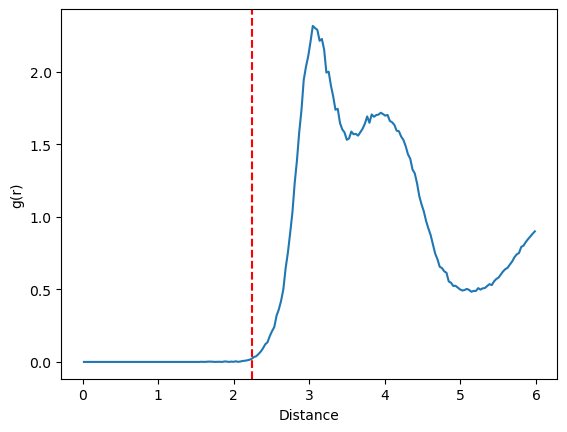

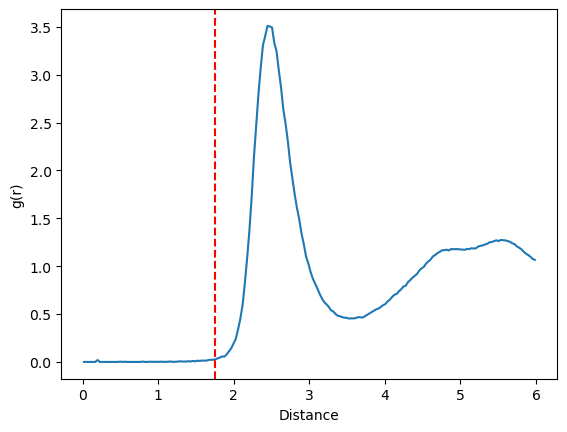


Results saved to 'flow.csv'


TypeError: 'NoneType' object is not subscriptable

In [3]:
cfg = load_config("/Users/rasmus/Documents/GitHub/TopologicalMaterialAnalysis/examples/max_flow/example.yaml", cli_overrides={})
cfg = load_config("/Volumes/external_1/max_flow_electrolytes/anders_data/LiPS/max_flow.yaml", cli_overrides={})

if cfg.verbose:
    print("=" * 60)
    print(f"System : backbone={cfg.backbone_atoms}  flow={cfg.flow_atoms}")
    print(f"Output : {cfg.output_csv}")
    print("=" * 60)

cfg.trajectory_path = "/Users/rasmus/Library/CloudStorage/OneDrive-AalborgUniversitet/Projects/RA2-Topology/Data_math/Electrolytes & Reeb-graphs/Li2S-P2S5/Series_2/75-25_1/MSD/300/md.statsis3"
#"/Users/rasmus/Documents/GitHub/TopologicalMaterialAnalysis/examples/max_flow/md_stats.lammpstrj"

results = run_flow_analysis(cfg)

pd.DataFrame([results]).rename(
    columns={
        "flow": "Flow",
        "slice_area": "Slice Area",
        "norm_flow": "Normalized Flow",
    }
).to_csv(cfg.output_csv, index=False)

print(f"\nResults saved to '{cfg.output_csv}'")
print(f"  Flow            : {results['flow']:.4f}")
print(f"  Slice area      : {results['slice_area']:.4f} Å²")
print(f"  Normalised flow : {results['norm_flow']:.6f}")